In [1]:
from ctd_toolkit.utils.sql_query import SQLQuery
from ctd_toolkit.backend.read_argo import ReadArgo
from ctd_toolkit.backend.read_meop import ReadMEOP
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib qt

In [2]:
path = "'C:/Users/m1_gui01/Desktop/oceano/profile_list_without_depth.parquet'"

In [3]:
source = SQLQuery()

In [24]:
month = f"""SELECT EXTRACT(MONTH FROM timestamp) AS month, source, COUNT(*) AS count_per_source FROM {path}
GROUP BY EXTRACT(MONTH FROM timestamp), source ORDER BY month, source"""

year = f"""SELECT EXTRACT(YEAR FROM timestamp) AS year, fn, source, COUNT(*) AS count_per_source FROM {path}
WHERE year <= 2026
GROUP BY EXTRACT(YEAR FROM timestamp), source, fn ORDER BY year, source"""

lat = f"""SELECT ROUND(lat, 0) AS lat_r, fn, source, COUNT(*) AS count_per_source FROM {path}
GROUP BY lat_r, source, fn ORDER BY lat_r, source"""
# WHERE lat_r BETWEEN -75 AND -40


lon = f"""SELECT ROUND(lon, 0) AS lon_r, fn, source, COUNT(*) AS count_per_source FROM {path}
GROUP BY lon_r, source, fn ORDER BY lon_r, source"""
# WHERE lon_r BETWEEN 30 AND 120



In [25]:
import numpy as np
df = source.query(lon)

In [32]:
df[np.isnan(df.lon_r.to_numpy()) & (df.source == 'MEOP')].to_csv('C:/Users/m1_gui01/Desktop/longitude_nan.csv')

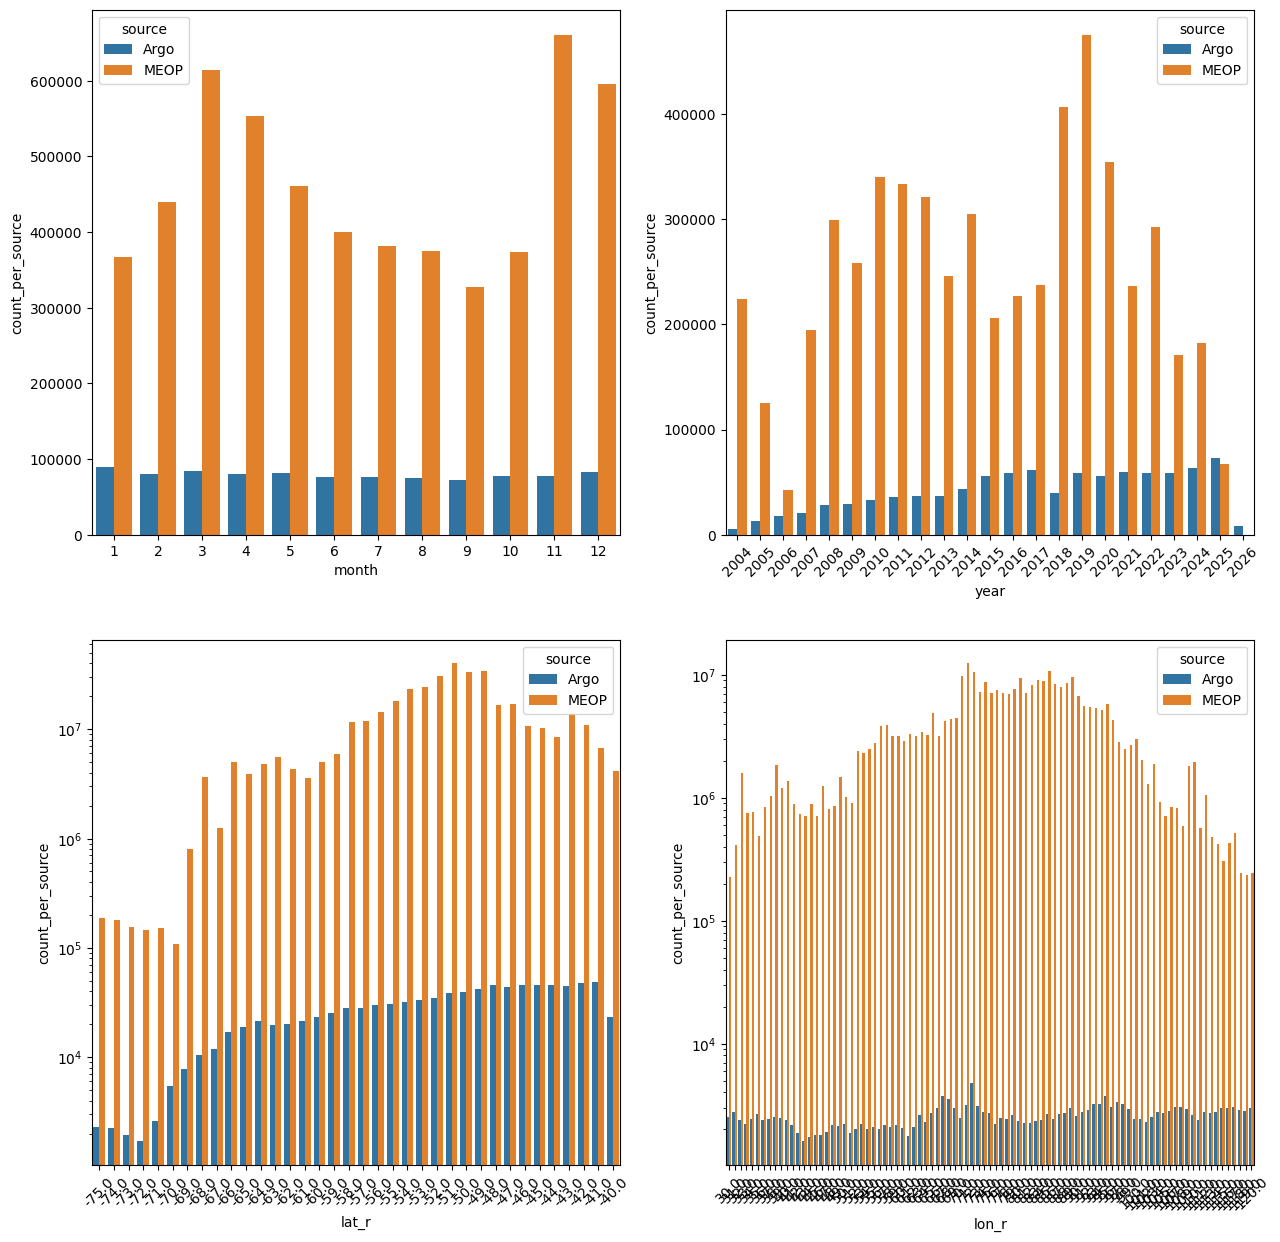

In [21]:
fig, ax = plt.subplots(2,2, figsize = (15, 15))
ax = ax.flatten()

sns.barplot(source.query(month), x = 'month', y = 'count_per_source', hue = 'source', ax = ax[0])
sns.barplot(source.query(year), x = 'year', y = 'count_per_source', hue = 'source', ax = ax[1])
sns.barplot(source.query(lat), x = 'lat_r', y = 'count_per_source', hue = 'source', ax = ax[2])
sns.barplot(source.query(lon), x = 'lon_r', y = 'count_per_source', hue = 'source', ax = ax[3])
ax[1].tick_params(axis='x', rotation=45)
ax[2].set_yscale('log')
ax[2].tick_params(axis='x', rotation=45)
ax[3].set_yscale('log')
ax[3].tick_params(axis='x', rotation=45)